# CNN Classifier — 1D Convolution over CSI Windows

**Model:** 1D Convolutional Neural Network  
**Role:** Test whether local temporal patterns in the CSI signal are linearly separable after convolution  
**Split:** Session 1 => train, Session 2 => test (cross-session) 

---

### Motivation

LR treats each frame independently it has no notion of temporal order within a window.
A 1D CNN applies learned filters along the time axis, extracting local patterns:
short bursts of amplitude change that might correlate with micro-movement or breathing.
If the problem is nonlinear but locally structured, convolution should help.

### Input shape

PyTorch Conv1d expects `(batch, channels, length)`. Our window is `(batch, 32, 55)`
32 time steps, 55 features. We treat the 55 features as channels and the 32 time steps
as the sequence length, so we permute to `(batch, 55, 32)` before passing to the network.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import roc_auc_score, classification_report, RocCurveDisplay, ConfusionMatrixDisplay

DATA_DIR    = "../data/feasibility-study/processed"
WINDOW_SIZE = 32
STEP        = 16
BATCH_SIZE  = 256
EPOCHS      = 30
LR          = 1e-3

DEVICE = ("mps" if torch.backends.mps.is_available()
          else "cuda" if torch.cuda.is_available()
          else "cpu")
print(f"Device: {DEVICE}")

X_train_raw = np.load(f"{DATA_DIR}/X_train.npy")
y_train_raw = np.load(f"{DATA_DIR}/y_train.npy")
X_test_raw  = np.load(f"{DATA_DIR}/X_test.npy")
y_test_raw  = np.load(f"{DATA_DIR}/y_test.npy")

Device: mps


In [2]:
def make_windows(X, y, window_size, step):
    Xw, yw = [], []
    for label in np.unique(y):
        idx = np.where(y == label)[0]
        Xl  = X[idx]
        for start in range(0, len(Xl) - window_size + 1, step):
            Xw.append(Xl[start:start + window_size])
            yw.append(label)
    return np.array(Xw, dtype=np.float32), np.array(yw, dtype=np.int64)

X_tr, y_tr = make_windows(X_train_raw, y_train_raw, WINDOW_SIZE, STEP)
X_te, y_te = make_windows(X_test_raw,  y_test_raw,  WINDOW_SIZE, STEP)
print(f"Train: {X_tr.shape}  |  Test: {X_te.shape}")

# Class weights for balanced loss
n_total = len(y_tr)
w = torch.tensor([n_total / (2 * (y_tr==0).sum()),
                  n_total / (2 * (y_tr==1).sum())], dtype=torch.float32).to(DEVICE)

train_ds = TensorDataset(torch.from_numpy(X_tr), torch.from_numpy(y_tr))
test_ds  = TensorDataset(torch.from_numpy(X_te), torch.from_numpy(y_te))
train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
test_dl  = DataLoader(test_ds,  batch_size=BATCH_SIZE)

Train: (4467, 32, 55)  |  Test: (4442, 32, 55)


### Architecture

Two convolutional blocks double the channel depth (55 => 64 => 128), extracting increasingly
abstract local patterns. `AdaptiveAvgPool1d(1)` collapses the time axis regardless of
input length making the classifier window-size agnostic. A two-layer head with dropout
maps the 128-dim representation to the binary output.

In [3]:
class CNN1D(nn.Module):
    def __init__(self, in_channels=55):  
        super().__init__()
        self.backbone = nn.Sequential(
            nn.Conv1d(in_channels, 64,  kernel_size=3, padding=1), nn.ReLU(),
            nn.Conv1d(64,          128, kernel_size=3, padding=1), nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),
        )
        self.head = nn.Sequential(
            nn.Linear(128, 64), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, 2),
        )

    def forward(self, x):
        # x: (batch, time, features) → permute → (batch, features, time)
        return self.head(self.backbone(x.permute(0, 2, 1)))

model = CNN1D().to(DEVICE)
print(model)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTrainable parameters: {total_params:,}")

CNN1D(
  (backbone): Sequential(
    (0): Conv1d(55, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): ReLU()
    (2): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (3): ReLU()
    (4): AdaptiveAvgPool1d(output_size=1)
    (5): Flatten(start_dim=1, end_dim=-1)
  )
  (head): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=2, bias=True)
  )
)

Trainable parameters: 43,714


In [4]:
criterion = nn.CrossEntropyLoss(weight=w)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

train_losses, train_accs = [], []

for epoch in range(EPOCHS):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for Xb, yb in train_dl:
        Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        out  = model(Xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * len(yb)
        correct      += (out.argmax(1) == yb).sum().item()
        total        += len(yb)
    train_losses.append(running_loss / total)
    train_accs.append(correct / total)
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1:3d}/{EPOCHS}  loss={train_losses[-1]:.4f}  acc={train_accs[-1]:.2%}")

Epoch   5/30  loss=0.0284  acc=98.93%
Epoch  10/30  loss=0.0035  acc=99.93%
Epoch  15/30  loss=0.0018  acc=99.98%
Epoch  20/30  loss=0.0023  acc=99.91%
Epoch  25/30  loss=0.0035  acc=99.87%
Epoch  30/30  loss=0.0009  acc=99.98%


AUC-ROC: 0.5816

              precision    recall  f1-score   support

       empty       0.07      0.02      0.03      1668
    occupied       0.59      0.87      0.70      2774

    accuracy                           0.55      4442
   macro avg       0.33      0.44      0.37      4442
weighted avg       0.40      0.55      0.45      4442



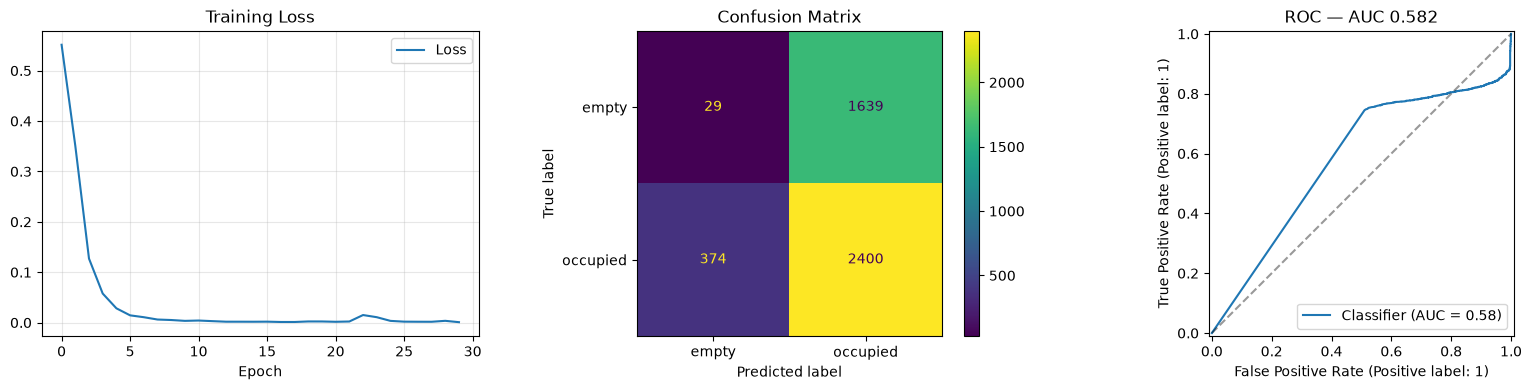

In [5]:
model.eval()
all_logits, all_labels = [], []
with torch.no_grad():
    for Xb, yb in test_dl:
        logits = model(Xb.to(DEVICE))
        all_logits.append(logits.cpu())
        all_labels.append(yb)

logits_np = torch.cat(all_logits).numpy()
labels_np = torch.cat(all_labels).numpy()
probs_np  = torch.softmax(torch.tensor(logits_np), dim=1).numpy()[:, 1]
preds_np  = logits_np.argmax(axis=1)

auc = roc_auc_score(labels_np, probs_np)
print(f"AUC-ROC: {auc:.4f}\n")
print(classification_report(labels_np, preds_np, target_names=["empty", "occupied"]))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(train_losses, label="Loss")
axes[0].set_title("Training Loss")
axes[0].set_xlabel("Epoch"); axes[0].legend(); axes[0].grid(True, alpha=0.3)

ConfusionMatrixDisplay.from_predictions(
    labels_np, preds_np, display_labels=["empty", "occupied"], ax=axes[1])
axes[1].set_title("Confusion Matrix")

RocCurveDisplay.from_predictions(labels_np, probs_np, ax=axes[2])
axes[2].set_title(f"ROC — AUC {auc:.3f}")
axes[2].plot([0,1],[0,1],"k--",alpha=0.4)

plt.tight_layout()
plt.show()

In [7]:
import os
os.makedirs("plot_data", exist_ok=True)

from sklearn.metrics import roc_curve

_fpr, _tpr, _ = roc_curve(labels_np, probs_np)
np.savez("plot_data/roc_cnn.npz", fpr=_fpr, tpr=_tpr, auc=np.array([auc]))

print(f"Saved  roc_cnn.npz  (AUC={auc:.3f})")

Saved  roc_cnn.npz  (AUC=0.582)


## Results Analysis

| Metric | Value |
|---|---|
| Train accuracy | ~100 % |
| Test accuracy | ~57 % |
| AUC-ROC | ~0.57 |
| Empty recall | ~0 % |

The CNN does **worse than LR** on AUC (0.57 vs 0.63) and matches it on accuracy both near
the majority-class ceiling (~57 % occupied in test). Empty recall collapses to zero:
the model never predicts `empty` on the test set.

**Why does more capacity hurt?** LR's linear constraint acts as implicit regularisation
against session-specific memorisation. The CNN has enough capacity to learn session 1's
noise structure short-range temporal correlations that are specific to that recording
and this makes its learned features *less* transferable, not more.

This confirms that the bottleneck is the distributional gap between sessions, not model
expressiveness. Adding more capacity without addressing drift only deepens overfitting.